# 02. Đánh giá chính sách dưới cùng ngân sách

Chỉ tiêu chính của dự án là **N(π) = số chuyến hoàn thành mỗi ngày** khi mọi chính sách dùng **cùng ngân sách voucher B** (5.545,80 USD/kỳ); lợi nhuận V(π) là chỉ tiêu phụ. Chương này:

1. Bảng N(π), V(π) của 15 chính sách dưới cùng B (T5.1).
2. Bậc thang: mỗi lớp của chính sách thêm bao nhiêu chuyến (H-22 i).
3. Đường N(π_θ) theo ngưỡng θ: hai cách đo độ căng ŝ × hai hàm điểm (B7b và ba sweep S5; H-22 ii, H-25).
4. Ví dụ hàm điểm có Qini cao hơn mà N thấp hơn (T5.2, tiêu chí nghiệm thu 3), và vì sao.

Chủ notebook: Tình (T6.2, H-27). Phép tính trong `analysis/policy_table.py`, `analysis/metrics.py`, `analysis/qini_vs_value.py`; hình trong `analysis/figures.py`.

Cách so sánh: mọi chính sách chạy trên **cùng 30 seed** với số ngẫu nhiên chung (CRN), nên hiệu giữa hai chính sách lấy **ghép cặp theo seed** (A2: CRN giảm phương sai của hiệu 6–7 lần). κ (ngưỡng điểm của tầng rider) chọn tự động để chi tiêu vừa B (κ auto điểm bất động, H-21).

**Dữ liệu cần** (lệnh sinh lại ở `docs/datasets.md`, mục B7b và S5):

| Thư mục | Nội dung |
|---|---|
| `runs/s5/policy_table` | `python -m analysis.policy_table --n-seeds 30`: 15 chính sách × 30 seed |
| `runs/b7b_h21/sweep_theta_ref` | sweep θ, ŝ theo ô, `heuristic_low_freq` (B7b bản H-21) |
| `runs/s5/sweep_ring1_heuristic`, `runs/s5/sweep_cell_dr`, `runs/s5/sweep_ring1_dr` | sweep θ: ŝ `ring1` và/hoặc hàm điểm DR/USD |
| `runs/s5/qini_vs_value` | `python -m analysis.qini_vs_value` với `--outcome completed` và `requested` |

In [1]:
from analysis.notebook import require_runs, setup
from analysis.plots import save_figure

plt = setup()   # repository root, shared plot style, wide pandas display
(table_dir, sweep_ref_dir, ring1_heur_dir, cell_dr_dir, ring1_dr_dir, qini_dir) = require_runs(
    "runs/s5/policy_table", "runs/b7b_h21/sweep_theta_ref", "runs/s5/sweep_ring1_heuristic",
    "runs/s5/sweep_cell_dr", "runs/s5/sweep_ring1_dr", "runs/s5/qini_vs_value")

In [2]:
import pandas as pd
from IPython.display import Markdown, display

from analysis import figures, policy_table
from analysis.metrics import sweep_by_theta, sweep_overview
from analysis.qini_vs_value import efficiency_markdown, policy_runs

runs = policy_runs(table_dir)
print("B =", runs["budget_B_usd"].dropna().iloc[0], "USD/kỳ;", runs["seed"].nunique(), "seed;",
      runs["label"].nunique(), "chính sách")

B = 5545.8 USD/kỳ; 30 seed; 15 chính sách


## 1. N(π) và V(π) dưới cùng B (T5.1)

Các chính sách (nhãn trong bảng):

- `all_off`: không voucher (không chi). `all_on_B`: phát cho mọi session theo thứ tự đến cho tới khi hết B của kỳ; là **mốc** so sánh.
- π_θ với θ = 0 (không tắt ô nào), chỉ khác **hàm điểm** của tầng rider: `random`, `heuristic` (ưu tiên rider tần suất thấp), τ̂(x) và τ̂(x)/USD bảng nền (H4.2), τ̂(x), τ̂(x, s) học bằng DR-learner (H-24), có bản /USD (chia cho chi phí kỳ vọng của một lượt phát) và bản học chỉ trên lát explore.
- π_θ có tầng ô: θ = 0,5 với heuristic; π_θ̂ với ŝ `ring1` và θ̂ (A) = 0,25, θ̂ (B) = 5 của H5.3, cùng hàm điểm τ̂(x)/USD DR.

Cột "N − all_on_B" là hiệu ghép cặp theo seed (± SE).

In [3]:
summary = policy_table.summarize(runs)
display(Markdown(policy_table.markdown(summary)))

| Chính sách | θ | κ | N (± SE) | V (USD, ± SE) | Chi / B | % (ô, slot) tắt | N − all_on_B (± SE) |
|---|---|---|---|---|---|---|---|
| `all_off` | — | — | 3.440,1 ± 10,3 | 15.666,8 ± 40,2 | — | 100 | −246,6 ± 5,2 |
| `all_on_B` | — | — | 3.686,7 ± 10,3 | 11.515,6 ± 43,6 | 1,000 | 0 | 0 (mốc) |
| `random` | 0,00 | 0,730 | 3.807,0 ± 11,2 | 12.243,9 ± 40,7 | 0,983 | 0 | 120,3 ± 5,1 |
| `heuristic` | 0,00 | −2,236 | 3.860,3 ± 11,0 | 12.378,0 ± 40,9 | 0,996 | 0 | 173,5 ± 4,7 |
| `tau_x` | 0,00 | 0,090 | 3.803,7 ± 10,5 | 12.279,6 ± 39,5 | 0,992 | 0 | 117,0 ± 6,4 |
| `tau_per_usd` | 0,00 | 0,103 | 4.002,0 ± 10,1 | 12.888,6 ± 37,1 | 0,988 | 0 | 315,3 ± 5,3 |
| `tau_x_dr_all` | 0,00 | 0,122 | 3.752,7 ± 10,6 | 12.021,6 ± 42,3 | 0,997 | 0 | 66,0 ± 5,4 |
| `tau_xs_dr_all` | 0,00 | 0,139 | 3.780,3 ± 10,4 | 12.181,7 ± 40,5 | 0,987 | 0 | 93,6 ± 5,6 |
| `tau_x_dr_all_usd` | 0,00 | 0,113 | 3.989,9 ± 10,1 | 12.834,7 ± 39,7 | 0,988 | 0 | 303,2 ± 6,7 |
| `tau_xs_dr_all_usd` | 0,00 | 0,128 | 4.010,3 ± 12,1 | 12.981,0 ± 45,5 | 0,979 | 0 | 323,6 ± 6,4 |
| `tau_x_dr_usd` | 0,00 | 0,106 | 3.934,9 ± 10,3 | 12.646,7 ± 41,8 | 0,994 | 0 | 248,2 ± 4,5 |
| `tau_xs_dr_usd` | 0,00 | 0,108 | 3.929,2 ± 12,1 | 12.695,6 ± 42,8 | 0,976 | 0 | 242,5 ± 6,0 |
| `pi_theta_0.5_heuristic` | 0,50 | −2,574 | 3.894,9 ± 10,3 | 12.580,8 ± 35,6 | 0,985 | 33 | 208,1 ± 5,4 |
| `pi_thetahatA_ring1_dr_usd` | 0,25 | 0,112 | 4.011,8 ± 11,8 | 12.980,5 ± 41,2 | 0,983 | 10 | 325,0 ± 5,8 |
| `pi_thetahatB_ring1_dr_usd` | 5,00 | −∞ | 3.849,2 ± 9,1 | 12.784,6 ± 62,8 | 0,890 | 70 | 162,5 ± 6,2 |

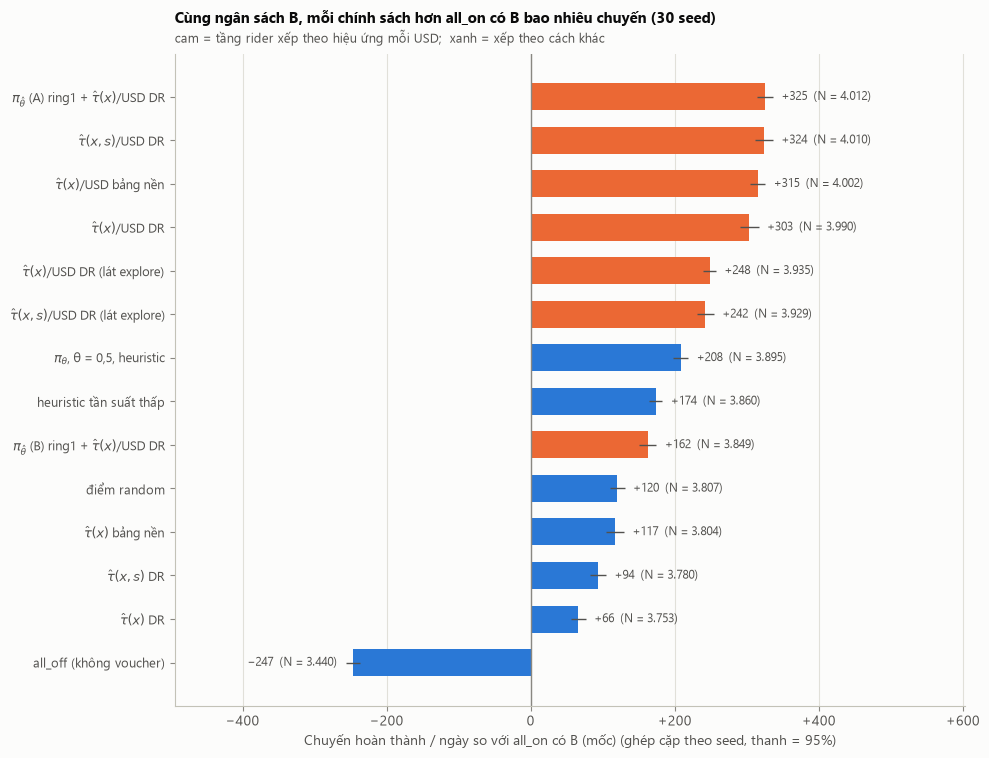

In [4]:
fig = figures.ladder_figure(summary)
save_figure(fig, "02_n_duoi_b")
plt.show()

**Đọc kết quả.**

- Mọi chính sách đều tiêu gần hết B (cột chi / B 0,98–1,00), trừ π_θ̂ (B) chỉ tiêu 0,89 B vì tầng ô tắt 70% (ô, slot). So sánh vì vậy là "cùng tiền, bao nhiêu chuyến".
- Nhóm đứng đầu (màu cam trong hình) đều **xếp rider theo hiệu ứng mỗi USD**: hơn `all_on_B` từ +242 đến +325 chuyến/ngày; riêng bảng nền τ̂(x)/USD hơn `random` +195. Xếp theo hiệu ứng mỗi lượt phát (τ̂(x), τ̂(x, s) không chia USD) không hơn `random`, thậm chí kém.
- V(π) đi cùng chiều N ở nhóm đầu: chính sách nhiều chuyến nhất dưới cùng B cũng có lợi nhuận cao nhất trong các chính sách có voucher. `all_off` có V cao nhất vì không chi voucher, nhưng ít hơn 247 chuyến/ngày so với `all_on_B`.

## 2. Bậc thang: mỗi lớp thêm bao nhiêu chuyến (H-22 i)

Theo H-22, θ\* luôn báo **kèm hàm điểm, B và bậc thang này**, thay cho một con số "π_θ hơn all_on". Mỗi bậc là hiệu ghép cặp theo seed giữa hai chính sách chỉ khác một lớp.

In [5]:
steps = [
    ("all_on_B", "random", "rải ngân sách cả ngày (κ chặn theo điểm ngẫu nhiên)"),
    ("random", "heuristic", "xếp rider theo heuristic tần suất thấp"),
    ("heuristic", "pi_theta_0.5_heuristic", "thêm tầng ô θ = 0,5 (ŝ theo ô)"),
    ("random", "tau_per_usd", "xếp rider theo hiệu ứng mỗi USD (bảng nền)"),
    ("tau_per_usd", "tau_x_dr_all_usd", "thay bảng nền bằng DR-learner"),
    ("tau_x_dr_all_usd", "tau_xs_dr_all_usd", "đưa trạng thái cung s vào hàm điểm"),
    ("tau_x_dr_all_usd", "pi_thetahatA_ring1_dr_usd", "thay vào đó: thêm tầng ô ring1, θ̂ (A) = 0,25"),
    ("tau_xs_dr_all_usd", "pi_thetahatA_ring1_dr_usd", "hai cách đưa cung vào, so với nhau"),
]
ladder = policy_table.paired_steps(runs, [(a, b) for a, b, _ in steps])
ladder.insert(0, "bậc", [text for _, _, text in steps])
ladder.round(1)

,bậc,from,to,from_mean,to_mean,diff,diff_se,n_seeds
0,rải ngân sách cả ngày (κ chặn theo điểm ngẫu n...,all_on_B,random,3686.7,3807.0,120.3,5.1,30
1,xếp rider theo heuristic tần suất thấp,random,heuristic,3807.0,3860.3,53.2,4.3,30
2,"thêm tầng ô θ = 0,5 (ŝ theo ô)",heuristic,pi_theta_0.5_heuristic,3860.3,3894.9,34.6,3.7,30
3,xếp rider theo hiệu ứng mỗi USD (bảng nền),random,tau_per_usd,3807.0,4002.0,195.0,3.9,30
4,thay bảng nền bằng DR-learner,tau_per_usd,tau_x_dr_all_usd,4002.0,3989.9,-12.1,4.4,30
5,đưa trạng thái cung s vào hàm điểm,tau_x_dr_all_usd,tau_xs_dr_all_usd,3989.9,4010.3,20.4,4.9,30
6,"thay vào đó: thêm tầng ô ring1, θ̂ (A) = 0,25",tau_x_dr_all_usd,pi_thetahatA_ring1_dr_usd,3989.9,4011.8,21.8,4.6,30
7,"hai cách đưa cung vào, so với nhau",tau_xs_dr_all_usd,pi_thetahatA_ring1_dr_usd,4010.3,4011.8,1.4,4.0,30


**Đọc kết quả.**

- Bậc lớn nhất là **không tiêu hết ngân sách buổi sáng** (`all_on_B` → `random`, khoảng +120): `all_on_B` hết tiền giữa ngày, còn κ chặn theo điểm thì rải chi tiêu cả ngày.
- Bậc lớn thứ hai là **xếp hạng theo hiệu ứng mỗi USD** (khoảng +195 so với `random`), hơn hẳn heuristic cộng tầng ô (+53 + 35).
- Khi hàm điểm đã theo USD, đưa trạng thái cung vào **hàm điểm** (τ̂(x, s)/USD) hay vào **tầng ô** (`ring1`, θ̂ (A)) đều thêm khoảng +20 chuyến/ngày, và hai cách cho kết quả như nhau (hiệu ≈ 0): chúng thay thế nhau. Phần lợi do trạng thái cung nhỏ hơn một bậc so với phần lợi do chi phí.
- DR-learner chưa hơn bảng nền H4.2 trên N (bậc "thay bảng nền bằng DR-learner" âm), dù có Qini cao hơn (mục 4).

## 3. Đường N(π_θ) theo θ

π_θ tắt khuyến mãi ở (ô, slot) có độ căng dự báo ŝ < θ, rồi phát cho rider có điểm ≥ κ trong các ô còn bật; κ chọn lại cho từng θ để chi tiêu vừa B. Bốn sweep cùng lưới 16 θ, cùng 30 seed:

- ŝ **theo ô** (slack của chính ô, slot trước) hoặc **`ring1`** (tổng xe rảnh / tổng xe đi đón của ô và 6 ô kề, H-25);
- hàm điểm `heuristic_low_freq` hoặc τ̂(x)/USD DR (`analysis.uplift:tau_x_dr_all_per_dollar`).

Tập θ\* là các θ **không kém θ tốt nhất** ở mức 5% đồng thời (so sánh bội với cái tốt nhất, Bonferroni, ghép cặp theo seed; T-31). Regret của θ = 0 = N(θ tốt nhất) − N(θ = 0).

In [6]:
sweep_dirs = {("heuristic tần suất thấp", "cell"): sweep_ref_dir, ("heuristic tần suất thấp", "ring1"): ring1_heur_dir,
              (figures.DR_TITLE, "cell"): cell_dr_dir, (figures.DR_TITLE, "ring1"): ring1_dr_dir}
sweep_results = {key: pd.read_parquet(d / "results" / "policy_results.parquet") for key, d in sweep_dirs.items()}
overview = sweep_overview({f"{'ô' if scope == 'cell' else 'ring1'}, {'heuristic' if 'heuristic' in score else 'DR/USD'}": r
                           for (score, scope), r in sweep_results.items()}, theta_hats=(0.25, 5.0))
overview.round(2)

,sweep,theta_best,mean_best,star_lo,star_hi,star_gaps,mean_theta0,n_seeds,regret_0,regret_0_se,regret_0.25,regret_0.25_se,regret_5,regret_5_se
0,"ô, heuristic",2.0,3899.73,0.3,2.0,[1.0],3860.27,30,39.47,4.04,9.63,3.07,22.87,3.87
1,"ring1, heuristic",3.0,3915.70,1.5,3.0,[2.0],3860.27,30,55.43,4.69,30.48,4.21,66.50,3.87
2,"ô, DR/USD",0.4,4006.57,0.1,0.6,[],3989.93,30,16.63,5.66,1.62,3.80,87.17,5.38
3,"ring1, DR/USD",1.0,4017.37,0.2,1.5,[],3989.93,30,27.43,4.10,5.12,3.13,168.17,5.27


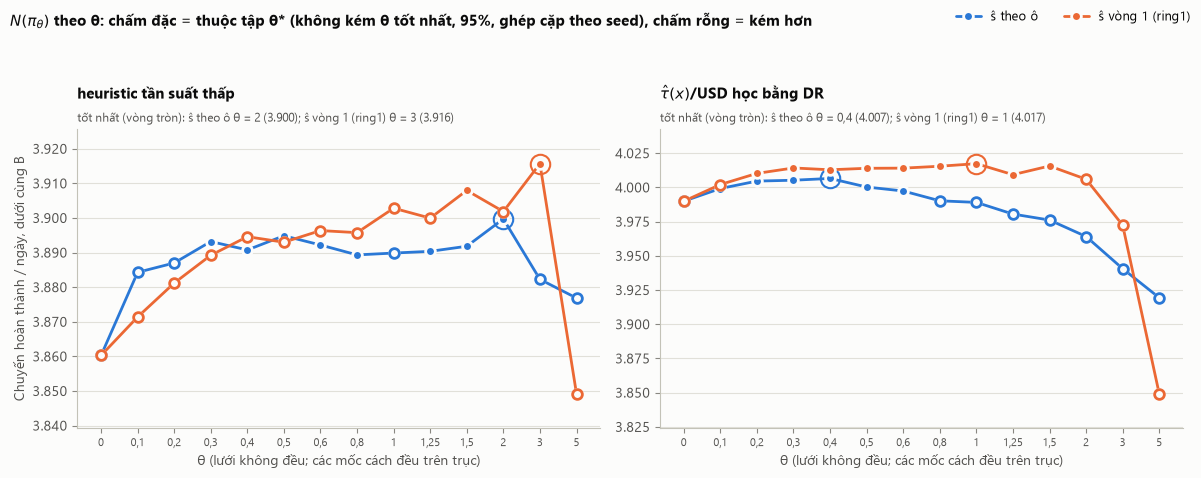

In [7]:
fig = figures.sweeps_figure({key: sweep_by_theta(r) for key, r in sweep_results.items()})
save_figure(fig, "02_n_theo_theta")
plt.show()

**Đọc kết quả.**

- **Dự đoán ghi trước của H-22 (ii), "hàm điểm càng tốt thì θ\* càng gần 0", đúng trên cả hai cách đo ŝ.** Thay heuristic bằng DR/USD, tập θ\* dời từ [0,3; 2] về [0,1; 0,6] (ŝ theo ô) và từ [1,5; 3] về [0,2; 1,5] (`ring1`); regret của θ = 0 giảm khoảng một nửa. θ = 0 vẫn chưa thuộc tập θ\*: tầng ô vẫn có ích, nhưng ít.
- Lý do (§2.8 của báo cáo phương pháp): dưới ngân sách, tầng ô có lợi chủ yếu vì nó **dồn tiền** khỏi những nơi mỗi USD đổi được ít chuyến; hàm điểm /USD đã làm việc đó ở mức rider, nên phần còn lại cho tầng ô nhỏ.
- `ring1` hơn ŝ theo ô ở θ tốt nhất khoảng +11 đến +16 chuyến/ngày. Hiệu này chọn "tốt nhất" trên chính các seed đo nên hơi lớn hơn thật (winner's curse). Hai thang θ không so trực tiếp được: ở cùng θ, `ring1` tắt ít (ô, slot) hơn khi θ nhỏ và nhiều hơn khi θ lớn. Với `ring1`, θ > `slack_cap` = 10 là `all_off` (T-35 e).
- Regret của θ̂ (A) = 0,25 và θ̂ (B) = 5 (cột `regret_0.25`, `regret_5`) là đầu vào của notebook 04 (Hoàng): trên `ring1` + DR/USD, θ̂ (A) gần như không mất gì, θ̂ (B) cắt quá tay.

## 4. Qini cao hơn mà N thấp hơn (T5.2)

Một nhóm làm uplift sẽ chọn hàm điểm theo **Qini** trên dữ liệu ngẫu nhiên hóa. Qini ở đây tính trên A/B theo rider của B7a (`rider_ab_28d`, 28 ngày, kết cục hoàn thành chuyến), khoảng tin cậy bootstrap theo rider (200 lần). N lấy từ bảng T5.1 (π_θ θ = 0 với hàm điểm đó, dưới B).

Một cặp (a, b) là ví dụ khi Qini(a) > Qini(b) và N(a) < N(b), **cả hai hiệu có khoảng 95% không chứa 0** (T-33).

In [8]:
res = qini_dir / "results"
qini = pd.read_parquet(res / "qini_completed.parquet")
efficiency = pd.read_parquet(res / "offer_efficiency.parquet")
n_mean = runs.groupby("label")["N_completed"].mean()
display(qini.assign(N_mean=qini["label"].map(n_mean)).sort_values("qini_coef", ascending=False)
        [["label", "qini_coef", "qini_lo", "qini_hi", "N_mean"]].round(1))
for outcome in ("completed", "requested"):
    pairs = pd.read_parquet(res / f"qini_pairs_{outcome}.parquet")
    print(f"{outcome}: {int(pairs['qini_higher_n_lower'].sum())} / {len(pairs) // 2} cặp có Qini cao hơn mà N thấp hơn")

,label,qini_coef,qini_lo,qini_hi,N_mean
7,tau_xs_dr_all,1600.6,1090.8,2106.8,3780.3
4,tau_x_dr_all,1055.1,472.7,1707.8,3752.7
3,tau_x,862.6,418.6,1313.7,3803.7
6,tau_x_dr_usd,96.7,-479.0,725.8,3934.9
9,tau_xs_dr_usd,90.3,-488.9,615.5,3929.2
1,random,59.8,-154.6,256.1,3807.0
8,tau_xs_dr_all_usd,-443.8,-1140.7,233.7,4010.3
2,tau_per_usd,-619.0,-1336.3,-2.0,4002.0
5,tau_x_dr_all_usd,-756.5,-1490.4,-16.3,3989.9
0,heuristic,-985.9,-1820.6,-172.2,3860.3


completed: 28 / 45 cặp có Qini cao hơn mà N thấp hơn
requested: 28 / 45 cặp có Qini cao hơn mà N thấp hơn


In [9]:
pairs = pd.read_parquet(res / "qini_pairs_completed.parquet")
pairs[pairs["qini_higher_n_lower"]].sort_values("dN").head(8)[["a", "b", "dqini", "dqini_lo", "dqini_hi", "dN", "dN_se"]].round(1)

,a,b,dqini,dqini_lo,dqini_hi,dN,dN_se
43,tau_x_dr_all,tau_xs_dr_all_usd,1498.9,503.9,2562.6,-257.6,5.2
38,tau_x_dr_all,tau_per_usd,1674.1,606.6,2735.2,-249.3,4.6
40,tau_x_dr_all,tau_x_dr_all_usd,1811.6,741.1,2851.0,-237.2,5.6
70,tau_xs_dr_all,tau_xs_dr_all_usd,2044.4,1177.3,3022.2,-230.0,6.1
65,tau_xs_dr_all,tau_per_usd,2219.6,1306.0,3228.7,-221.7,5.0
68,tau_xs_dr_all,tau_x_dr_all_usd,2357.2,1482.6,3331.3,-209.6,6.4
34,tau_x,tau_xs_dr_all_usd,1306.3,409.2,2216.3,-206.6,6.7
29,tau_x,tau_per_usd,1481.6,682.3,2407.0,-198.3,5.3


Tiêu chí nghiệm thu 3 đạt, với nhiều ví dụ. Câu hỏi tiếp theo là **vì sao**: do trạng thái cung (hàm điểm Qini cao dồn voucher vào nơi thiếu xe), hay do chi phí?

Để tách hai cơ chế, lấy đúng κ của mỗi hàm điểm trong bảng T5.1, coi session có điểm ≥ κ là "được phát", rồi đo trên chính dữ liệu A/B theo rider (chợ giữ nguyên, không có tranh chấp cung giữa hai nhánh): q₀, q₁ là tỷ lệ hoàn thành khi không và có voucher. Voucher chỉ trả khi chuyến hoàn thành, nên chi phí một lượt phát là v·q₁ và số chuyến thêm mỗi USD là (1 − q₀/q₁)/v (`analysis.qini_vs_value.offer_efficiency`, T-36).

In [10]:
display(Markdown(efficiency_markdown(efficiency)))

| Hàm điểm | N dưới B | Session được phát | Voucher / lượt phát (USD) | q0 / q1 | Chuyến thêm / 100 USD |
|---|---|---|---|---|---|
| `tau_xs_dr_all_usd` | 4.010,3 | 41% | 4,98 | 0,077 / 0,137 | 12,28 |
| `tau_per_usd` | 4.002,0 | 46% | 5,04 | 0,071 / 0,129 | 12,54 |
| `tau_x_dr_all_usd` | 3.989,9 | 45% | 5,04 | 0,073 / 0,129 | 12,11 |
| `tau_x_dr_usd` | 3.934,9 | 38% | 5,04 | 0,087 / 0,149 | 11,24 |
| `tau_xs_dr_usd` | 3.929,2 | 38% | 5,03 | 0,084 / 0,145 | 11,26 |
| `heuristic` | 3.860,3 | 39% | 5,03 | 0,089 / 0,142 | 9,49 |
| `random` | 3.807,0 | 27% | 5,04 | 0,126 / 0,193 | 8,61 |
| `tau_x` | 3.803,7 | 22% | 5,05 | 0,159 / 0,231 | 7,74 |
| `tau_xs_dr_all` | 3.780,3 | 14% | 4,91 | 0,234 / 0,320 | 6,44 |
| `tau_x_dr_all` | 3.752,7 | 18% | 5,05 | 0,207 / 0,281 | 6,37 |

Spearman(N dưới B, chuyến thêm / 100 USD ở mức cá nhân) = 0,976 trên 10 hàm điểm

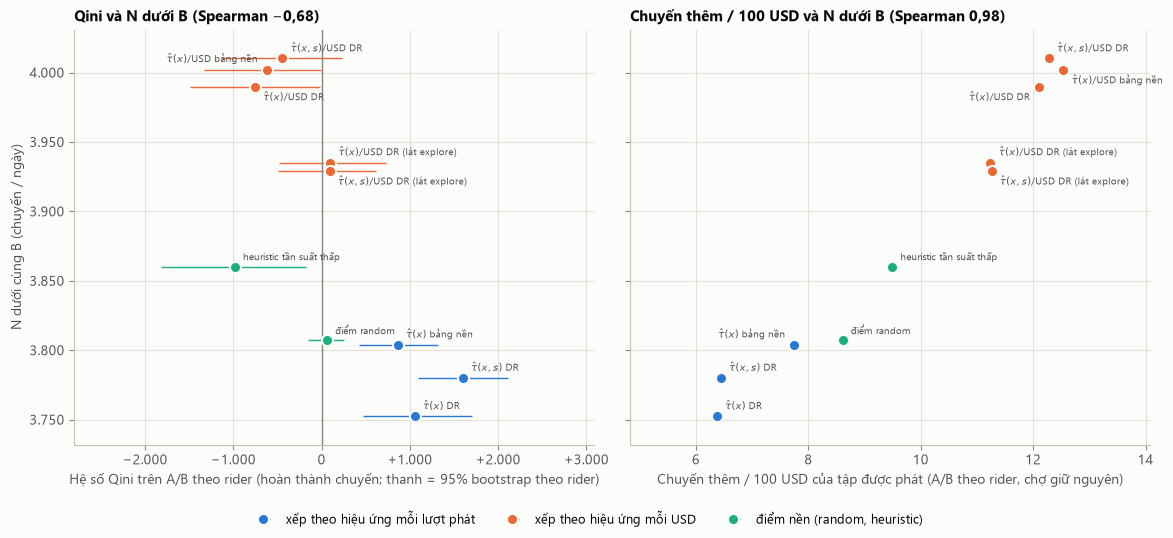

In [11]:
fig = figures.qini_vs_n_figure(qini, efficiency)
save_figure(fig, "02_qini_va_n")
plt.show()

**Đọc kết quả.**

- Thứ hạng N dưới B của 10 hàm điểm **trùng gần hoàn toàn** với thứ hạng "chuyến thêm / 100 USD" đo ở mức cá nhân trên A/B (Spearman ≈ 0,98), mà phép đo này không có cân bằng thị trường. Với Qini, tương quan **âm**.
- Voucher mỗi lượt phát gần như bằng nhau giữa các hàm điểm (4,9–5,05 USD), nên khác biệt không nằm ở cỡ voucher. Nó nằm ở **trả tiền cho chuyến đằng nào cũng có**: hàm điểm Qini cao chọn rider hay đi (q₀ 0,21–0,23 so với 0,13 trung bình). Uplift mỗi lượt phát của họ lớn nhất, nhưng phần lớn tiền trả cho chuyến không tăng thêm. Đây là cùng lập luận với ngưỡng q₁/q₀ ≥ c/(c − r) ở §1.5 của báo cáo phương pháp.
- **Trong thế giới mặc định chưa có ví dụ đảo thứ tự do trạng thái cung:** phần do cung (đưa s vào điểm /USD, hoặc tầng ô) chỉ khoảng +20 chuyến/ngày, nhỏ hơn một bậc so với phần do chi phí (khoảng 200). Muốn thấy kênh cung lớn hơn cần kịch bản căng hơn (cầu × 1,5, thiếu xe); đó là việc mở cho sau S6.

## Tóm tắt

1. Cùng ngân sách, chính sách tốt nhất hơn `all_on_B` khoảng **+325 chuyến/ngày (+8,8%)** và hơn `all_off` khoảng **+570**. Gần như toàn bộ phần lợi đến từ hai việc: rải chi tiêu cả ngày, và xếp rider theo **hiệu ứng mỗi USD**.
2. Tầng ô theo độ căng cung (θ) thêm một phần nhỏ, càng nhỏ khi hàm điểm càng tốt (θ\* dời về 0, H-22 ii). Đưa trạng thái cung vào hàm điểm cho cùng mức lợi.
3. Qini xếp hàm điểm **ngược** với N dưới ngân sách. Cơ chế là chi phí (voucher trả cho chuyến đằng nào cũng có), không phải tranh chấp cung. Chọn hàm điểm có Qini cao nhất (τ̂(x, s) DR) thay vì bản /USD của chính nó mất 230 chuyến/ngày.

Chính sách khuyến nghị (H-26): ŝ `ring1`, hàm điểm τ̂(x)/USD DR, θ = 0,25; chi tiết ở notebook 04.